# this notebooks is strictiy to read a json file visualize the annotations present in a single image

In [4]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import cv2


def find_repo_root(start: Path, path_entries: list[str]) -> Path:
    checked = set()
    search_roots = [start.resolve()]

    for entry in path_entries:
        if not entry:
            continue
        try:
            search_roots.append(Path(entry).resolve())
        except OSError:
            continue

    for root in search_roots:
        for candidate in [root, *root.parents]:
            candidate_str = str(candidate)
            if candidate_str in checked:
                continue
            checked.add(candidate_str)
            if (candidate / "src" / "cnt_project").exists() and (candidate / "notebooks").exists():
                return candidate

    raise RuntimeError(
        f"Could not infer repository root from cwd={start} or the current sys.path entries."
    )


REPO_ROOT = find_repo_root(Path.cwd(), sys.path)
SRC_ROOT = REPO_ROOT / "src"

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from cnt_project.io.paths import ProjectPaths

PATHS = ProjectPaths.from_here(SRC_ROOT / "cnt_project" / "io" / "paths.py")
PATHS.ensure_outputs()

print("Project root:", PATHS.project_root)
print("Data root:", PATHS.data_root)

Project root: C:\Users\abd93000\PycharmProjects\cnt_project_v2
Data root: C:\Users\abd93000\PycharmProjects\cnt_project_v2\data


In [5]:
def read_json(file_path: str) -> dict:
    """Read and load JSON data from a file.

    Args:
        file_path (str): Path to the JSON file.

    Returns:
        dict: Loaded JSON data.
    """
    with open(file_path, 'r') as file:
        data = json.load(file)
    return data

In [6]:
# Paths
input_gt_json_path = PATHS.test_coco_json

# Load GT JSON
input_gt_json = read_json(input_gt_json_path)

# Image params
image_height = 256
image_width = 256
filename = "400-1093-w11-c1p1-befo3-10sp-15flow_left.jpg"

# --- Step 1: Extract image_id from GT JSON ---
image_id = None
for img in input_gt_json.get('images', []):
    if img.get('file_name') == filename:
        image_id = img.get('id')
        break

if image_id is None:
    raise ValueError(f"Filename '{filename}' not found in input_gt_json['images'].")

# --- Step 2: Extract GT features ---
image_annotations_gt = [ann for ann in input_gt_json.get('annotations', []) if ann.get('image_id') == image_id]


# Just visualization and onformation printing (this visualization function has been made with chatgpt)

Number of annotations for image '400-1093-w11-c1p1-befo3-10sp-15flow_left.jpg': 163
Total annotations (objects): 163
Total segments: 186
Objects with multiple segments: 22
Average segments per object: 1.14
Objects with 1 segment(s): 141
Objects with 2 segment(s): 21
Objects with 3 segment(s): 1


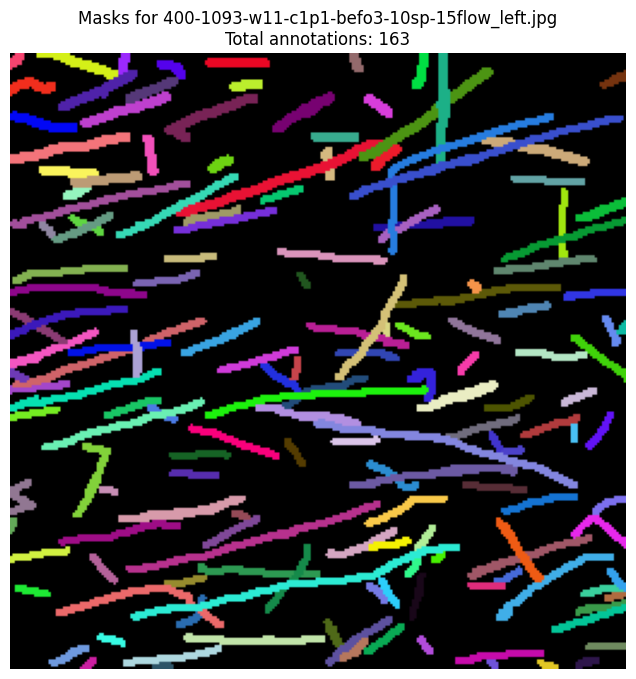

In [7]:
# Print number of annotations
print(f"Number of annotations for image '{filename}': {len(image_annotations_gt)}")

# Analyze segmentation details
total_segments = 0
objects_with_multiple_segments = 0
segmentation_counts = []

for i, ann in enumerate(image_annotations_gt):
    num_segments = len(ann['segmentation'])
    segmentation_counts.append(num_segments)
    total_segments += num_segments
    
    if num_segments > 1:
        objects_with_multiple_segments += 1
    else:
        continue

print(f"Total annotations (objects): {len(image_annotations_gt)}")
print(f"Total segments: {total_segments}")
print(f"Objects with multiple segments: {objects_with_multiple_segments}")
print(f"Average segments per object: {total_segments/len(image_annotations_gt):.2f}")

# Show segmentation count distribution
if len(image_annotations_gt) > 0:
    unique_counts = list(set(segmentation_counts))
    for count in sorted(unique_counts):
        num_objects = segmentation_counts.count(count)
        print(f"Objects with {count} segment(s): {num_objects}")


# Create a blank canvas to visualize masks
canvas = np.zeros((image_height, image_width, 3), dtype=np.uint8)

# Create a figure for plotting
plt.figure(figsize=(12, 8))

# Plot each annotation mask
for i, ann in enumerate(image_annotations_gt):
    # Create mask from segmentation
    mask = np.zeros((image_height, image_width), dtype=np.uint8)
    
    # COCO annotations can have multiple polygons for one object
    for segmentation in ann['segmentation']:
        # Reshape segmentation points
        poly = np.array(segmentation).reshape(-1, 2)
        # Create polygon mask
        cv2.fillPoly(mask, [poly.astype(np.int32)], 1)
    
    # Generate random color for this mask
    color = np.random.randint(0, 255, 3)
    
    # Apply mask with color
    canvas[mask == 1] = color
    

# Display the result
plt.imshow(canvas)
plt.title(f"Masks for {filename}\nTotal annotations: {len(image_annotations_gt)}")
plt.axis('off')
plt.show()
